# Project 1: Animal-10 CNN Image Classification

Progressive CNN models on the Animal-10 dataset, plus a transfer-learning model.

| # | Model | Key changes |
|---|-------|-------------|
| 1 | Baseline CNN | 3 conv blocks, Adam |
| 2 | Improved CNN | 5 conv blocks + Dropout |
| 3 | Advanced CNN | Augmentation + BatchNorm + Callbacks |
| 4 | Transfer Learning | Frozen MobileNetV2 backbone |

**Pipeline order:** config → gather → clean → label → stratified split → load to arrays → train.
Images are kept as raw `uint8` [0, 255]; normalization lives *inside* each model
(so it travels with the saved model and the transfer model can use its own scaling).


## Setup

In [7]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from pathlib import Path
from collections import Counter
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from tensorflow.keras import layers, models

print(f"TensorFlow version: {tf.__version__}")

TensorFlow version: 2.21.0


## Configuration

In [2]:
DATA_DIR    = "sample_data/animals10/raw-img"
IMG_SIZE    = (224, 224)
BATCH_SIZE  = 32
SEED        = 42
NUM_CLASSES = 10


In [1]:
!curl -L https://www.kaggle.com/api/v1/datasets/download/alessiocorrado99/animals10 -o ./animals10.zip

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed

  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0

  0  585M    0 76590    0     0   108k      0  1:32:10 --:--:--  1:32:10  108k
  2  585M    2 13.7M    0     0  8387k      0  0:01:11  0:00:01  0:01:10 13.8M
  6  585M    6 35.5M    0     0  13.2M      0  0:00:44  0:00:02  0:00:42 17.8M
 10  585M   10 61.8M    0     0  16.7M      0  0:00:34  0:00:03  0:00:31 20.6M
 14  585M   14 86.8M    0     0  18.5M      0  0:00:31  0:00:04  0:00:27 21.7M
 19  585M   19  111M    0     0  19.6M      0  0:00:29  0:00:05  0:00:24 22.3M
 22  585M   22  134M    0     0  20.1M      0  0:00:29  0:00:06  0:00:23 24.1M
 27  585M   27  160M    0     0  20.9M      0  0:00:27  0:00:07  0:00:20 25.0M
 31  585M   31  185M    0     0  21.3M      0  0:0

In [2]:
import zipfile

with zipfile.ZipFile('animals10.zip', 'r') as zip_ref:
    zip_ref.extractall('sample_data/animals10')

## Data Cleaning

Animal-10 ships with a handful of truncated / non-JPEG files that would crash
decoding later. Gather all paths first, then drop.

In [3]:
data_path = Path(DATA_DIR)
image_paths = sorted([str(p) for p in data_path.glob("*/*") if p.is_file()])
print(f"Found {len(image_paths)} files before cleaning")


def is_valid(path):
    try:
        Image.open(path).verify()
        return True
    except Exception:
        return False

bad = [p for p in image_paths if not is_valid(p)]
print(f"Dropping {len(bad)} unreadable files")
image_paths = [p for p in image_paths if p not in set(bad)]

labels_str   = [Path(p).parent.name for p in image_paths]
class_names  = sorted(set(labels_str))
class_to_idx = {name: i for i, name in enumerate(class_names)}
labels_int   = [class_to_idx[l] for l in labels_str]

print(f"Kept {len(image_paths)} images across {len(class_names)} classes")
print(f"Classes: {class_names}")

Found 26179 files before cleaning
Dropping 0 unreadable files
Kept 26179 images across 10 classes
Classes: ['butterfly', 'cat', 'chicken', 'cow', 'dog', 'elephant', 'horse', 'sheep', 'spider', 'squirrel']


## English Class Names (for plots & reports)

In [4]:
# Animal-10 folder names are Italian; map to English for readable plots.
IT_TO_EN = {
    "cane": "dog", "cavallo": "horse", "elefante": "elephant",
    "farfalla": "butterfly", "gallina": "chicken", "gatto": "cat",
    "mucca": "cow", "pecora": "sheep", "ragno": "spider", "scoiattolo": "squirrel",
}
display_names = [IT_TO_EN.get(c, c) for c in class_names]
print(dict(zip(class_names, display_names)))

{'butterfly': 'butterfly', 'cat': 'cat', 'chicken': 'chicken', 'cow': 'cow', 'dog': 'dog', 'elephant': 'elephant', 'horse': 'horse', 'sheep': 'sheep', 'spider': 'spider', 'squirrel': 'squirrel'}


## Stratified Split (80 / 10 / 10)

`stratify=` keeps each class's proportion identical across train / val / test —
important here because the dataset is imbalanced (~3.3:1 largest-to-smallest).

In [5]:
# 80% train, 20% temp  ->  temp split 50/50 into val/test
train_paths, temp_paths, train_labels, temp_labels = train_test_split(
    image_paths, labels_int, test_size=0.20, random_state=SEED, stratify=labels_int
)
val_paths, test_paths, val_labels, test_labels = train_test_split(
    temp_paths, temp_labels, test_size=0.50, random_state=SEED, stratify=temp_labels
)

print(f"Train : {len(train_paths)}")
print(f"Val   : {len(val_paths)}")
print(f"Test  : {len(test_paths)}")

Train : 20943
Val   : 2618
Test  : 2618


### Verify stratification

In [6]:
for name, y in [("train", train_labels), ("val", val_labels), ("test", test_labels)]:
    total = len(y)
    dist = Counter(y)
    pct = {display_names[k]: f"{dist[k] / total:.1%}" for k in range(NUM_CLASSES)}
    print(f"{name:5s} (n={total}): {pct}")

train (n=20943): {'butterfly': '8.1%', 'cat': '6.4%', 'chicken': '11.8%', 'cow': '7.1%', 'dog': '18.6%', 'elephant': '5.5%', 'horse': '10.0%', 'sheep': '7.0%', 'spider': '18.4%', 'squirrel': '7.1%'}
val   (n=2618): {'butterfly': '8.1%', 'cat': '6.4%', 'chicken': '11.8%', 'cow': '7.1%', 'dog': '18.6%', 'elephant': '5.5%', 'horse': '10.0%', 'sheep': '7.0%', 'spider': '18.4%', 'squirrel': '7.1%'}
test  (n=2618): {'butterfly': '8.1%', 'cat': '6.4%', 'chicken': '11.8%', 'cow': '7.1%', 'dog': '18.6%', 'elephant': '5.5%', 'horse': '10.0%', 'sheep': '7.0%', 'spider': '18.4%', 'squirrel': '7.1%'}


## Class Weights

The dataset is imbalanced, so weight the loss inversely to class frequency.

In [7]:
weights = compute_class_weight(
    "balanced", classes=np.arange(NUM_CLASSES), y=train_labels
)
class_weights = dict(enumerate(weights))
for i, w in class_weights.items():
    print(f"{display_names[i]:10s} weight={w:.3f}")

butterfly  weight=1.239
cat        weight=1.570
chicken    weight=0.845
cow        weight=1.403
dog        weight=0.538
elephant   weight=1.810
horse      weight=0.998
sheep      weight=1.438
spider     weight=0.543
squirrel   weight=1.406


## Load Images into Arrays

Decode every image once into memory as `uint8` [0, 255]. Kept as `uint8` (~1.3 GB
for the full set) instead of float32 (~5 GB) to stay light on a laptop.
Normalization happens *inside* each model, not here.

In [8]:
def load_images(paths, labels, img_size=IMG_SIZE):
    X = np.empty((len(paths), *img_size, 3), dtype=np.uint8)
    for i, p in enumerate(paths):
        img = tf.io.read_file(p)
        img = tf.io.decode_image(img, channels=3, expand_animations=False)
        img = tf.image.resize(img, img_size)          # returns float32 [0, 255]
        X[i] = tf.cast(img, tf.uint8).numpy()
    return X, np.array(labels)

# First run decodes ~26k images (a minute or two); everything after is in-memory.
X_train, y_train = load_images(train_paths, train_labels)
X_val,   y_val   = load_images(val_paths,   val_labels)
X_test,  y_test  = load_images(test_paths,  test_labels)

print(f"X_train: {X_train.shape}  {X_train.dtype}")
print(f"X_val  : {X_val.shape}")
print(f"X_test : {X_test.shape}")

X_train: (20943, 224, 224, 3)  uint8
X_val  : (2618, 224, 224, 3)
X_test : (2618, 224, 224, 3)


## Exploratory Data Analysis

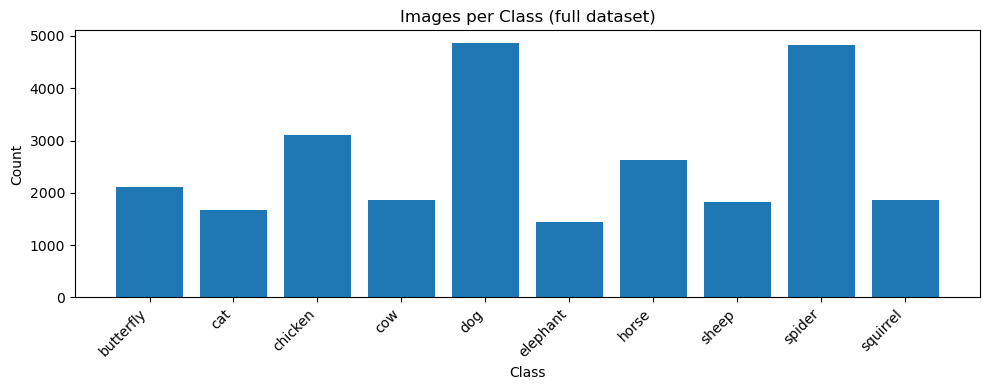

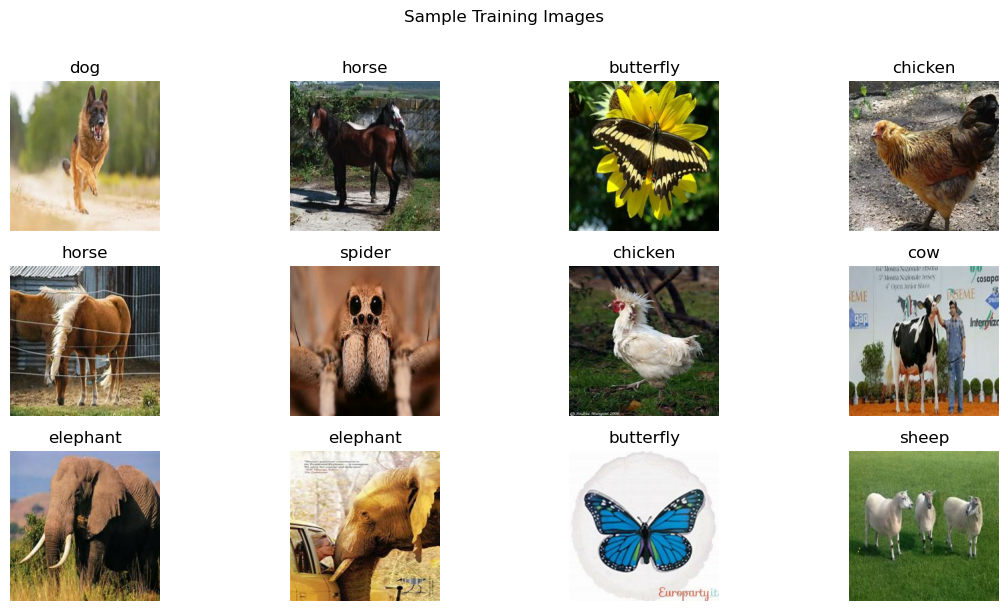

In [9]:
label_counts = Counter(labels_str)

plt.figure(figsize=(10, 4))
plt.bar(display_names, [label_counts[c] for c in class_names])
plt.xticks(rotation=45, ha="right")
plt.title("Images per Class (full dataset)")
plt.xlabel("Class")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 6))
for i in range(12):
    ax = plt.subplot(3, 4, i + 1)
    plt.imshow(X_train[i])
    plt.title(display_names[y_train[i]])
    plt.axis("off")
plt.suptitle("Sample Training Images", y=1.01)
plt.tight_layout()
plt.show()

## Helper Functions

In [10]:
results = {} 

def plot_history(history, title):
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    for ax, metric, ylabel in zip(axes, ["accuracy", "loss"], ["Accuracy", "Loss"]):
        ax.plot(history.history[metric], label="Train")
        ax.plot(history.history[f"val_{metric}"], label="Val")
        ax.set_title(f"{title} — {ylabel}")
        ax.set_xlabel("Epoch")
        ax.set_ylabel(ylabel)
        ax.legend()
    plt.tight_layout()
    plt.show()

def evaluate_and_record(model, name):
    loss, acc = model.evaluate(X_test, y_test, verbose=0)
    results[name] = (loss, acc)
    print(f"{name} — Test Loss: {loss:.4f} | Test Accuracy: {acc:.4f}")
    return loss, acc


callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss", patience=5, restore_best_weights=True
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss", factor=0.5, patience=2, min_lr=1e-6
    ),
]

---
## Model 1 — Baseline CNN
3 conv blocks → Flatten → Dense. `Rescaling` normalizes inside the model.

In [ ]:
model1 = models.Sequential([
    layers.Input(shape=(*IMG_SIZE, 3)),
    layers.Rescaling(1.0 / 255),

    layers.Conv2D(32, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dense(NUM_CLASSES, activation="softmax"),
], name="baseline_cnn")

model1.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)
model1.summary()

'model1 = models.Sequential([\n    layers.Input(shape=(*IMG_SIZE, 3)),\n    layers.Rescaling(1.0 / 255),\n\n    layers.Conv2D(32, (3, 3), activation="relu"),\n    layers.MaxPooling2D((2, 2)),\n\n    layers.Conv2D(64, (3, 3), activation="relu"),\n    layers.MaxPooling2D((2, 2)),\n\n    layers.Conv2D(128, (3, 3), activation="relu"),\n    layers.MaxPooling2D((2, 2)),\n\n    layers.Flatten(),\n    layers.Dense(128, activation="relu"),\n    layers.Dense(NUM_CLASSES, activation="softmax"),\n], name="baseline_cnn")\n\nmodel1.compile(\n    optimizer="adam",\n    loss="sparse_categorical_crossentropy",\n    metrics=["accuracy"],\n)\nmodel1.summary()\n'

In [ ]:
history1 = model1.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=10,
    batch_size=BATCH_SIZE,
    class_weight=class_weights,
)

plot_history(history1, "Model 1 — Baseline CNN")
evaluate_and_record(model1, "Model 1 — Baseline")

'history1 = model1.fit(\n    X_train, y_train,\n    validation_data=(X_val, y_val),\n    epochs=10,\n    batch_size=BATCH_SIZE,\n    class_weight=class_weights,\n)\n\nplot_history(history1, "Model 1 — Baseline CNN")\nevaluate_and_record(model1, "Model 1 — Baseline")\n'

---
## Model 2 — Improved CNN
5 conv blocks + Dropout to reduce overfitting.

In [ ]:
model2 = models.Sequential([
    layers.Input(shape=(*IMG_SIZE, 3)),
    layers.Rescaling(1.0 / 255),

    layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    layers.Conv2D(128, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.30),

    layers.Conv2D(256, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.30),

    layers.Conv2D(256, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.40),

    layers.Flatten(),
    layers.Dense(256, activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(NUM_CLASSES, activation="softmax"),
], name="improved_cnn")

model2.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)
model2.summary()

'model2 = models.Sequential([\n    layers.Input(shape=(*IMG_SIZE, 3)),\n    layers.Rescaling(1.0 / 255),\n\n    layers.Conv2D(32, (3, 3), activation="relu", padding="same"),\n    layers.MaxPooling2D((2, 2)),\n    layers.Dropout(0.25),\n\n    layers.Conv2D(64, (3, 3), activation="relu", padding="same"),\n    layers.MaxPooling2D((2, 2)),\n    layers.Dropout(0.25),\n\n    layers.Conv2D(128, (3, 3), activation="relu", padding="same"),\n    layers.MaxPooling2D((2, 2)),\n    layers.Dropout(0.30),\n\n    layers.Conv2D(256, (3, 3), activation="relu", padding="same"),\n    layers.MaxPooling2D((2, 2)),\n    layers.Dropout(0.30),\n\n    layers.Conv2D(256, (3, 3), activation="relu", padding="same"),\n    layers.MaxPooling2D((2, 2)),\n    layers.Dropout(0.40),\n\n    layers.Flatten(),\n    layers.Dense(256, activation="relu"),\n    layers.Dropout(0.5),\n    layers.Dense(NUM_CLASSES, activation="softmax"),\n], name="improved_cnn")\n\nmodel2.compile(\n    optimizer="adam",\n    loss="sparse_categoric

In [ ]:

history2 = model2.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=15,
    batch_size=BATCH_SIZE,
    class_weight=class_weights,
)

plot_history(history2, "Model 2 — Improved CNN")
evaluate_and_record(model2, "Model 2 — Improved")


'history2 = model2.fit(\n    X_train, y_train,\n    validation_data=(X_val, y_val),\n    epochs=15,\n    batch_size=BATCH_SIZE,\n    class_weight=class_weights,\n)\n\nplot_history(history2, "Model 2 — Improved CNN")\nevaluate_and_record(model2, "Model 2 — Improved")'

---
## Model 3 — Advanced CNN

In [ ]:

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
], name="augmentation")

model3 = models.Sequential([
    layers.Input(shape=(*IMG_SIZE, 3)),
    data_augmentation,
    layers.Rescaling(1.0 / 255),

    layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
    layers.BatchNormalization(),
    layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
    layers.BatchNormalization(),
    layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.30),

    layers.Conv2D(128, (3, 3), activation="relu", padding="same"),
    layers.BatchNormalization(),
    layers.Conv2D(128, (3, 3), activation="relu", padding="same"),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.40),

    layers.Conv2D(256, (3, 3), activation="relu", padding="same"),
    layers.BatchNormalization(),
    layers.Conv2D(256, (3, 3), activation="relu", padding="same"),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.40),

    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation="relu"),
    layers.BatchNormalization(),
    layers.Dropout(0.5),
    layers.Dense(NUM_CLASSES, activation="softmax"),
], name="advanced_cnn")

model3.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)
model3.summary()

'data_augmentation = tf.keras.Sequential([\n    layers.RandomFlip("horizontal"),\n    layers.RandomRotation(0.1),\n    layers.RandomZoom(0.1),\n], name="augmentation")\n\nmodel3 = models.Sequential([\n    layers.Input(shape=(*IMG_SIZE, 3)),\n    data_augmentation,\n    layers.Rescaling(1.0 / 255),\n\n    layers.Conv2D(32, (3, 3), activation="relu", padding="same"),\n    layers.BatchNormalization(),\n    layers.Conv2D(32, (3, 3), activation="relu", padding="same"),\n    layers.BatchNormalization(),\n    layers.MaxPooling2D((2, 2)),\n    layers.Dropout(0.25),\n\n    layers.Conv2D(64, (3, 3), activation="relu", padding="same"),\n    layers.BatchNormalization(),\n    layers.Conv2D(64, (3, 3), activation="relu", padding="same"),\n    layers.BatchNormalization(),\n    layers.MaxPooling2D((2, 2)),\n    layers.Dropout(0.30),\n\n    layers.Conv2D(128, (3, 3), activation="relu", padding="same"),\n    layers.BatchNormalization(),\n    layers.Conv2D(128, (3, 3), activation="relu", padding="same"),

In [ ]:

callbacks3 = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss", patience=8, restore_best_weights=True
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss", factor=0.5, patience=3, min_lr=1e-6
    ),
]

history3 = model3.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=BATCH_SIZE,
    class_weight=class_weights,
    callbacks=callbacks3,
)

plot_history(history3, "Model 3 — Advanced CNN")
evaluate_and_record(model3, "Model 3 — Advanced")


'callbacks3 = [\n    tf.keras.callbacks.EarlyStopping(\n        monitor="val_loss", patience=8, restore_best_weights=True\n    ),\n    tf.keras.callbacks.ReduceLROnPlateau(\n        monitor="val_loss", factor=0.5, patience=3, min_lr=1e-6\n    ),\n]\n\nhistory3 = model3.fit(\n    X_train, y_train,\n    validation_data=(X_val, y_val),\n    epochs=50,\n    batch_size=BATCH_SIZE,\n    class_weight=class_weights,\n    callbacks=callbacks3,\n)\n\nplot_history(history3, "Model 3 — Advanced CNN")\nevaluate_and_record(model3, "Model 3 — Advanced")'

---
## Model 4 — Transfer Learning (MobileNetV2)


In [17]:

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1),
], name="augmentation")

base_model = tf.keras.applications.MobileNetV2(
    input_shape=(*IMG_SIZE, 3),
    include_top=False,
    weights="imagenet",
)
base_model.trainable = False

inputs  = layers.Input(shape=(*IMG_SIZE, 3))
x = data_augmentation(inputs)
x = layers.Rescaling(1.0 / 127.5, offset=-1)(x)
x = base_model(x, training=False)          # <- keeps BatchNorm frozen even when fine-tuning
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(NUM_CLASSES, activation="softmax")(x)

model4 = tf.keras.Model(inputs, outputs, name="transfer_mobilenetv2")

model4.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)
model4.summary()

Model: "transfer_mobilenetv2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ augmentation (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │        12,810 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,270,794 (8.66 MB)

 Trainable params: 12,810 (50.04 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [18]:
history4 = model4.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=10,
    batch_size=BATCH_SIZE,
    class_weight=class_weights,
    callbacks=callbacks,
)

Epoch 1/10
655/655 ━━━━━━━━━━━━━━━━━━━━ 216s 321ms/step - accuracy: 0.8742 - loss: 0.4230 - val_accuracy: 0.9549 - val_loss: 0.1675 - learning_rate: 0.0010
Epoch 2/10
655/655 ━━━━━━━━━━━━━━━━━━━━ 208s 318ms/step - accuracy: 0.9228 - loss: 0.2590 - val_accuracy: 0.9561 - val_loss: 0.1579 - learning_rate: 0.0010
Epoch 3/10
655/655 ━━━━━━━━━━━━━━━━━━━━ 191s 292ms/step - accuracy: 0.9280 - loss: 0.2366 - val_accuracy: 0.9591 - val_loss: 0.1412 - learning_rate: 0.0010
Epoch 4/10
655/655 ━━━━━━━━━━━━━━━━━━━━ 220s 336ms/step - accuracy: 0.9308 - loss: 0.2260 - val_accuracy: 0.9641 - val_loss: 0.1332 - learning_rate: 0.0010
Epoch 5/10
655/655 ━━━━━━━━━━━━━━━━━━━━ 199s 303ms/step - accuracy: 0.9327 - loss: 0.2229 - val_accuracy: 0.9503 - val_loss: 0.1576 - learning_rate: 0.0010
Epoch 6/10
655/655 ━━━━━━━━━━━━━━━━━━━━ 179s 273ms/step - accuracy: 0.9368 - loss: 0.2076 - val_accuracy: 0.9618 - val_loss: 0.1330 - learning_rate: 0.0010
Epoch 7/10
655/655 ━━━━━━━━━━━━━━━━━━━━ 179s 273ms/step - accura

In [19]:
base_model.trainable = True

fine_tune_at = 100
for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

model4.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)
print(f"Trainable weights: {len(model4.trainable_weights)}")

Trainable weights: 56


Epoch 11/25
655/655 ━━━━━━━━━━━━━━━━━━━━ 329s 484ms/step - accuracy: 0.8986 - loss: 0.3316 - val_accuracy: 0.9626 - val_loss: 0.1355 - learning_rate: 1.0000e-05
Epoch 12/25
655/655 ━━━━━━━━━━━━━━━━━━━━ 307s 468ms/step - accuracy: 0.9193 - loss: 0.2515 - val_accuracy: 0.9622 - val_loss: 0.1334 - learning_rate: 1.0000e-05
Epoch 13/25
655/655 ━━━━━━━━━━━━━━━━━━━━ 285s 435ms/step - accuracy: 0.9330 - loss: 0.2117 - val_accuracy: 0.9645 - val_loss: 0.1284 - learning_rate: 1.0000e-05
Epoch 14/25
655/655 ━━━━━━━━━━━━━━━━━━━━ 285s 435ms/step - accuracy: 0.9377 - loss: 0.1909 - val_accuracy: 0.9626 - val_loss: 0.1322 - learning_rate: 1.0000e-05
Epoch 15/25
655/655 ━━━━━━━━━━━━━━━━━━━━ 291s 443ms/step - accuracy: 0.9418 - loss: 0.1755 - val_accuracy: 0.9652 - val_loss: 0.1262 - learning_rate: 1.0000e-05
Epoch 16/25
655/655 ━━━━━━━━━━━━━━━━━━━━ 323s 493ms/step - accuracy: 0.9472 - loss: 0.1528 - val_accuracy: 0.9664 - val_loss: 0.1224 - learning_rate: 1.0000e-05
Epoch 17/25
655/655 ━━━━━━━━━━━━━━

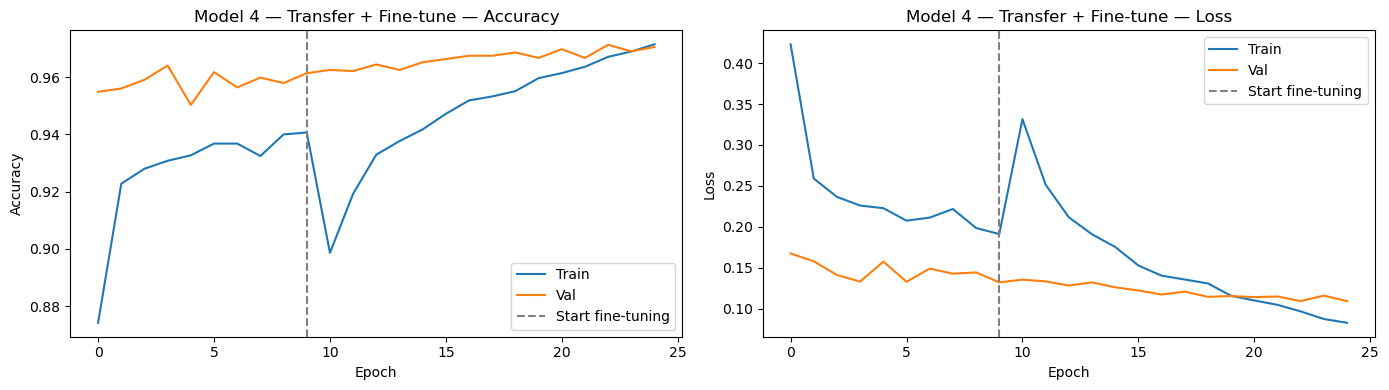

Model 4 — Transfer — Test Loss: 0.0977 | Test Accuracy: 0.9721


(0.09767966717481613, 0.9721161127090454)

In [20]:
initial_epochs = len(history4.epoch)
fine_tune_epochs = 15

history4_ft = model4.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=initial_epochs + fine_tune_epochs,
    initial_epoch=initial_epochs,
    batch_size=BATCH_SIZE,
    class_weight=class_weights,
    callbacks=callbacks,
)

acc  = history4.history["accuracy"]     + history4_ft.history["accuracy"]
vacc = history4.history["val_accuracy"] + history4_ft.history["val_accuracy"]
loss = history4.history["loss"]         + history4_ft.history["loss"]
vloss = history4.history["val_loss"]    + history4_ft.history["val_loss"]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, (tr, va), ylabel in zip(axes, [(acc, vacc), (loss, vloss)], ["Accuracy", "Loss"]):
    ax.plot(tr, label="Train")
    ax.plot(va, label="Val")
    ax.axvline(initial_epochs - 1, color="gray", ls="--", label="Start fine-tuning")
    ax.set_title(f"Model 4 — Transfer + Fine-tune — {ylabel}")
    ax.set_xlabel("Epoch"); ax.set_ylabel(ylabel); ax.legend()
plt.tight_layout()
plt.show()

evaluate_and_record(model4, "Model 4 — Transfer")


---
## Model Comparison

In [21]:
model_registry = {
    "Model 1 — Baseline": model1,
    "Model 2 — Improved": model2,
    "Model 3 — Advanced": model3,
    "Model 4 — Transfer": model4,
}

print(f"{'Model':<25} {'Loss':>8} {'Accuracy':>10}")
print("-" * 45)
for name, (loss, acc) in results.items():
    print(f"{name:<25} {loss:>8.4f} {acc:>10.4f}")

# Programmatic best-model selection (no hardcoding)
best_name  = max(results, key=lambda k: results[k][1])
best_model = model_registry[best_name]
print(f"\nBest model: {best_name} ({results[best_name][1]:.4f} accuracy)")

NameError: name 'model1' is not defined

---
## Best Model — Full Evaluation
Confusion matrix and per-class precision / recall / F1.

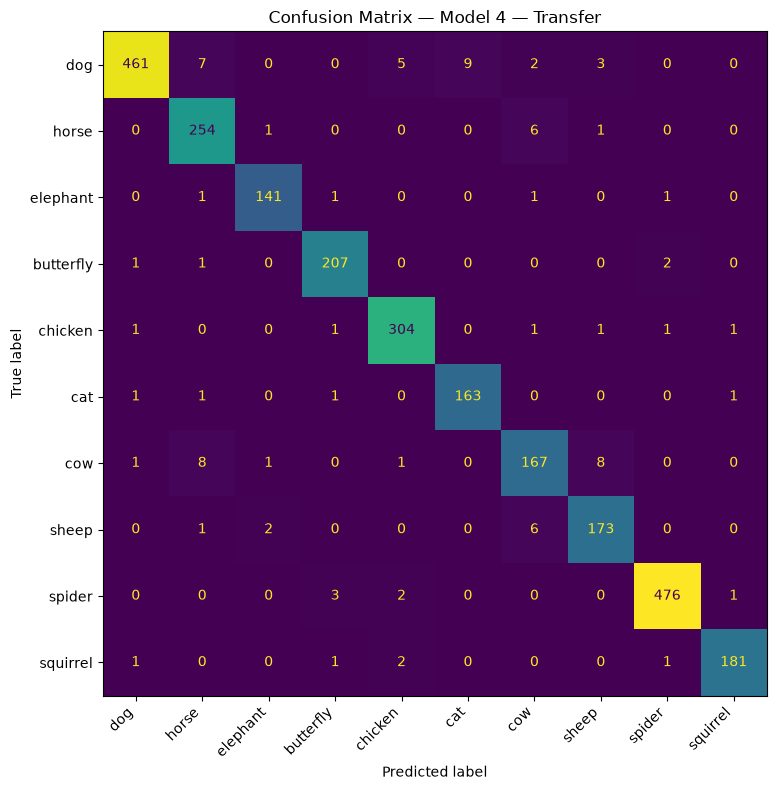

              precision    recall  f1-score   support

         dog       0.99      0.95      0.97       487
       horse       0.93      0.97      0.95       262
    elephant       0.97      0.97      0.97       145
   butterfly       0.97      0.98      0.97       211
     chicken       0.97      0.98      0.97       310
         cat       0.95      0.98      0.96       167
         cow       0.91      0.90      0.91       186
       sheep       0.93      0.95      0.94       182
      spider       0.99      0.99      0.99       482
    squirrel       0.98      0.97      0.98       186

    accuracy                           0.97      2618
   macro avg       0.96      0.96      0.96      2618
weighted avg       0.97      0.97      0.97      2618



In [ ]:
y_true = y_test
y_pred = np.argmax(best_model.predict(X_test, verbose=0), axis=1)

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(figsize=(10, 8))
ConfusionMatrixDisplay(cm, display_labels=display_names).plot(ax=ax, colorbar=False)
plt.xticks(rotation=45, ha="right")
plt.title(f"Confusion Matrix — {best_name}")
plt.tight_layout()
plt.show()

# Classification report (accuracy, precision, recall, F1 per class)
print(classification_report(y_true, y_pred, target_names=display_names))

### Misclassified examples

91 misclassified out of 2618


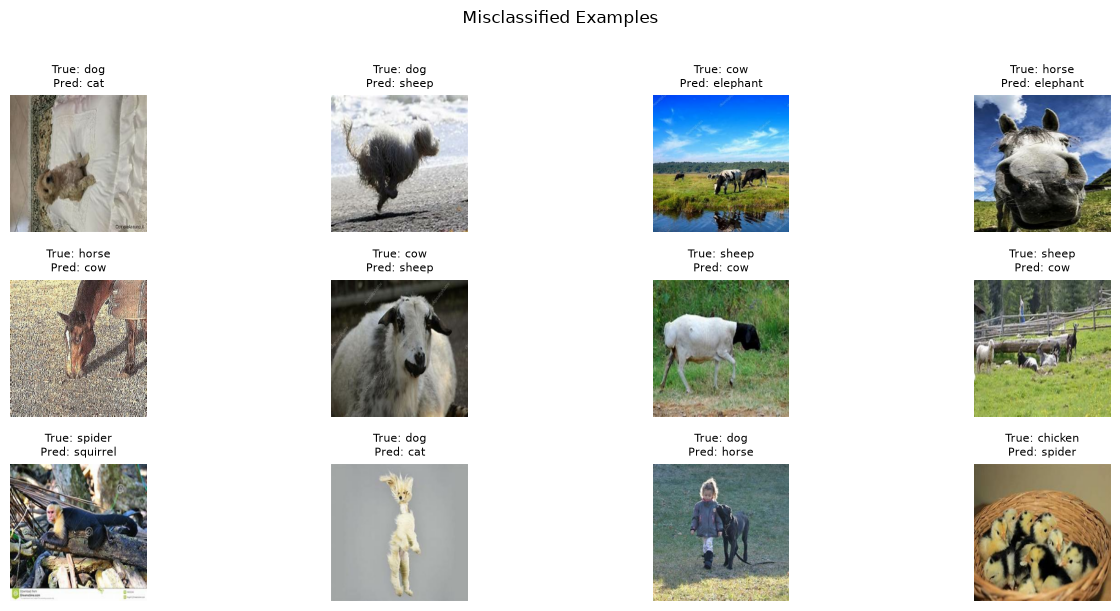

In [ ]:
mis = np.where(y_pred != y_true)[0]
print(f"{len(mis)} misclassified out of {len(y_true)}")

n_show = min(12, len(mis))
plt.figure(figsize=(14, 6))
for i in range(n_show):
    idx = mis[i]
    ax = plt.subplot(3, 4, i + 1)
    plt.imshow(X_test[idx])
    plt.title(f"True: {display_names[y_true[idx]]}\nPred: {display_names[y_pred[idx]]}",
              fontsize=8)
    plt.axis("off")
plt.suptitle("Misclassified Examples", y=1.01)
plt.tight_layout()
plt.show()

In [22]:
model4.save('animals_model.keras')